# try model for 1h

# Import Libraries



In [1]:
import numpy as np
import pandas as pd
import joblib
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import confusion_matrix, classification_report, f1_score
from sklearn.utils import class_weight
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Bidirectional, Dense, Dropout, LayerNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

2026-03-07 20:59:06.967917: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-03-07 20:59:06.968418: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-07 20:59:07.132313: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-07 20:59:09.631858: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To tur

# Load Data

In [2]:
df = pd.read_csv("data/BTC_ALL_HOURLY.csv")
df['datetime'] = pd.to_datetime(df['datetime'])
df = df.sort_values('datetime')

In [3]:
print("Data Loaded Successfully. Shape:", df.shape)

Data Loaded Successfully. Shape: (74836, 6)


In [4]:
print(f"🧹 Missing values before cleaning:\n{df.isnull().sum()}")
df.dropna(inplace=True)
df.sort_index(inplace=True)

🧹 Missing values before cleaning:
datetime    0
open        0
high        0
low         0
close       0
volume      0
dtype: int64


# Data Exploration (EDA)


In [5]:
df.head()


,datetime,open,high,low,close,volume
0,2017-08-17 04:00:00,4261.48,4313.62,4261.32,4308.83,47.181009
1,2017-08-17 05:00:00,4308.83,4328.69,4291.37,4315.32,23.234916
2,2017-08-17 06:00:00,4330.29,4345.45,4309.37,4324.35,7.229691
3,2017-08-17 07:00:00,4316.62,4349.99,4287.41,4349.99,4.443249
4,2017-08-17 08:00:00,4333.32,4377.85,4333.32,4360.69,0.972807


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 74836 entries, 0 to 74835
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   datetime  74836 non-null  datetime64[us]
 1   open      74836 non-null  float64       
 2   high      74836 non-null  float64       
 3   low       74836 non-null  float64       
 4   close     74836 non-null  float64       
 5   volume    74836 non-null  float64       
dtypes: datetime64[us](1), float64(5)
memory usage: 3.4 MB


In [7]:
df.describe()


,datetime,open,high,low,close,volume
count,74836,74836.000000,74836.000000,74836.000000,74836.000000,74836.000000
mean,2021-11-27 13:49:54.307552,36851.016673,37001.564862,36692.820444,36851.874718,2574.760733
min,2017-08-17 04:00:00,2870.900000,2950.000000,2817.000000,2919.000000,0.000000
25%,2019-10-09 12:45:00,9211.495000,9246.992500,9174.075000,9211.905000,752.894197
50%,2021-11-28 12:30:00,26771.575000,26845.780000,26691.845000,26772.635000,1395.532382
75%,2024-01-17 02:15:00,57867.567500,58146.277500,57585.740000,57868.040000,2717.285290
max,2026-03-06 15:00:00,126011.180000,126199.630000,125252.740000,126011.180000,137207.188600
std,NaN,32398.816181,32497.076909,32296.889244,32398.813822,3891.364361


# Feature Engineering

In [8]:
print("Engineering 15 Professional Features")

Engineering 15 Professional Features


### EMA

In [9]:
df['EMA_10'] = df['close'].ewm(span=10, adjust=False).mean()
df['EMA_20'] = df['close'].ewm(span=20, adjust=False).mean()
df['EMA_50'] = df['close'].ewm(span=50, adjust=False).mean()

## Momentum Indicators

### 1. RSI (14)

In [10]:
delta = df['close'].diff()
gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
df['RSI'] = 100 - (100 / (1 + (gain / loss)))

### 2. MACD (12, 26, 9)

In [11]:
exp12 = df['close'].ewm(span=12, adjust=False).mean()
exp26 = df['close'].ewm(span=26, adjust=False).mean()
df['MACD'] = exp12 - exp26
df['MACD_Signal'] = df['MACD'].ewm(span=9, adjust=False).mean()

### 3. Stochastic %K (14)

In [12]:
low_14 = df['low'].rolling(window=14).min()
high_14 = df['high'].rolling(window=14).max()
df['Stoch_K'] = 100 * ((df['close'] - low_14) / (high_14 - low_14))
df['Will_R'] = -100 * ((high_14 - df['close']) / (high_14 - low_14))

##  Volatility Indicators

### 1. ATR (Average True Range)

In [13]:
high_low = df['high'] - df['low']
high_pc = np.abs(df['high'] - df['close'].shift())
low_pc = np.abs(df['low'] - df['close'].shift())
tr = pd.concat([high_low, high_pc, low_pc], axis=1).max(axis=1)
df['ATR'] = tr.rolling(window=14).mean()

### 2. Bollinger Bands (20, 2) & BB Width

In [14]:
ma20 = df['close'].rolling(window=20).mean()
std20 = df['close'].rolling(window=20).std()
df['BB_Width'] = (std20 * 4) / ma20

## Cycles & Strength 

### 1. CCI (20)

In [15]:
tp = (df['high'] + df['low'] + df['close']) / 3
ma_tp = tp.rolling(window=20).mean()
mad_tp = tp.rolling(window=20).apply(lambda x: np.abs(x - x.mean()).mean())
df['CCI'] = (tp - ma_tp) / (0.015 * mad_tp)

## Returns

In [16]:
cols_to_pct = ['open', 'high', 'low', 'close', 'volume', 'EMA_10', 'EMA_20', 'EMA_50', 'ATR']
for col in cols_to_pct:
    df[col + '_ret'] = df[col].pct_change()

## Target

In [17]:
df['Target'] = (df['close'].shift(-24) > df['close']).astype(int)

In [18]:
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(inplace=True)

### test

In [19]:
df.describe()


,datetime,open,high,low,close,volume,EMA_10,EMA_20,EMA_50,RSI,...,open_ret,high_ret,low_ret,close_ret,volume_ret,EMA_10_ret,EMA_20_ret,EMA_50_ret,ATR_ret,Target
count,74813,74813.000000,74813.000000,74813.000000,74813.000000,74813.000000,74813.000000,74813.000000,74813.000000,74813.000000,...,74813.000000,74813.000000,74813.000000,74813.000000,74813.000000,74813.000000,74813.000000,74813.000000,74813.000000,74813.000000
mean,2021-11-28 00:04:54.205552,36860.099926,37010.676729,36701.869749,36860.956164,2575.379854,36857.019995,36852.571135,36839.213361,50.886943,...,0.000068,0.000060,0.000070,0.000067,0.155786,0.000040,0.000038,0.000038,0.002254,0.520284
min,2017-08-17 23:00:00,2870.900000,2950.000000,2817.000000,2919.000000,0.000000,3107.464635,3208.311460,3245.719244,0.547546,...,-0.182201,-0.129828,-0.243869,-0.182115,-1.000000,-0.047895,-0.030895,-0.015680,-0.450443,0.000000
25%,2019-10-10 04:00:00,9214.010000,9248.790000,9176.450000,9214.910000,753.337100,9211.639280,9209.998696,9214.189308,39.514754,...,-0.002473,-0.002261,-0.002067,-0.002480,-0.269560,-0.000733,-0.000551,-0.000384,-0.029974,0.000000
50%,2021-11-28 23:00:00,26779.450000,26848.070000,26702.630000,26779.790000,1395.793020,26801.605751,26795.211590,26778.609781,50.743969,...,0.000078,-0.000205,0.000352,0.000074,-0.033560,0.000060,0.000047,0.000038,-0.000472,1.000000
75%,2024-01-17 08:00:00,57877.970000,58150.000000,57599.570000,57877.970000,2717.847393,57831.722011,57854.979458,57773.696532,62.233130,...,0.002655,0.002067,0.002657,0.002672,0.310889,0.000867,0.000670,0.000493,0.028641,1.000000
max,2026-03-06 15:00:00,126011.180000,126199.630000,125252.740000,126011.180000,137207.188600,125062.361818,124694.100415,124031.476731,100.000000,...,0.173670,0.152525,0.271352,0.173840,190.760354,0.033865,0.020696,0.010494,1.701271,1.000000
std,NaN,32399.242186,32497.498599,32297.318552,32399.241479,3891.665299,32396.432938,32393.607577,32385.458176,16.425611,...,0.007824,0.006920,0.008053,0.007821,1.217032,0.002319,0.001629,0.001024,0.068748,0.499592


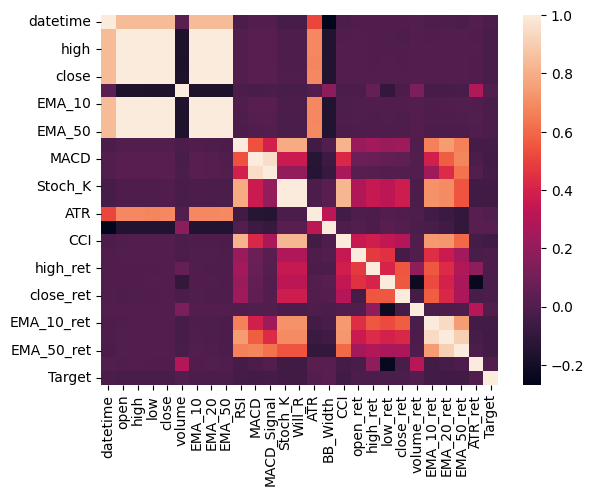

In [20]:
sns.heatmap(df.corr())
plt.show()
# !pip install seaborn

## remove the bad column  

In [21]:
df = df.drop("open", axis=1)
df = df.drop("low", axis=1)
df = df.drop("high", axis=1)
df = df.drop("close", axis=1)
# df = df.drop("BB_Upper", axis=1)
df = df.drop("EMA_50", axis=1)
df = df.drop("EMA_10", axis=1)
df = df.drop("EMA_20", axis=1)


In [22]:
df = df.drop(["BB_Lower", "ATR"], axis=1, errors='ignore')

final_features = [
    'close_ret', 'volume_ret', 'open_ret', 'ATR_ret', 'EMA_10_ret',
    'RSI', 'MACD', 'MACD_Signal', 'Stoch_K', 'Will_R',
    'BB_Width', 'CCI', 'high_ret' 
]

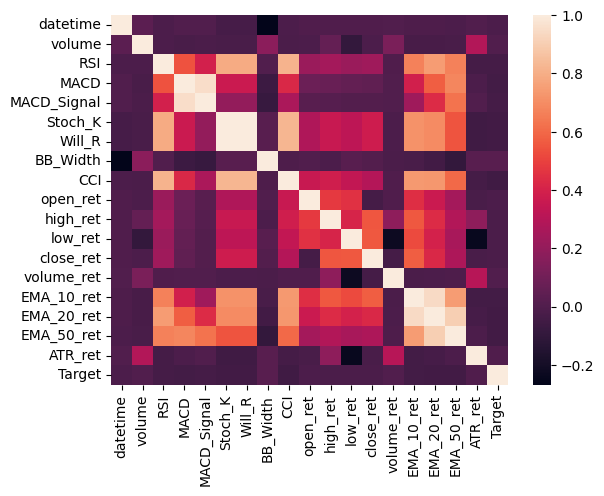

In [23]:
sns.heatmap(df.corr())
plt.show()

# Data Scaling

In [24]:
X_data = df[final_features].values
y_data = df['Target'].values

In [25]:
scaler = MinMaxScaler(feature_range=(0, 1))
X_scaled = scaler.fit_transform(X_data)

In [26]:
joblib.dump(scaler, "egx360_scaler.pkl")
print("Data Scaled and Scaler saved.")

Data Scaled and Scaler saved.


# Train / Test Split

In [27]:
split_idx = int(len(X_scaled) * 0.8)

In [28]:
train_data, test_data = X_scaled[:split_idx], X_scaled[split_idx:]
train_target, test_target = y_data[:split_idx], y_data[split_idx:]

In [29]:
print(f"📅 Training records: {len(train_data)} | Testing records: {len(test_data)}")

📅 Training records: 59850 | Testing records: 14963


# Create Sequences

In [30]:
def create_sequences(data, target, seq_len):
    xs, ys = [], []
    for i in range(len(data) - seq_len):
        xs.append(data[i : (i + seq_len)])
        ys.append(target[i + seq_len])
    return np.array(xs), np.array(ys)

SEQ_LEN = 22

In [31]:
X_train, y_train = create_sequences(train_data, train_target, SEQ_LEN)
X_test, y_test = create_sequences(test_data, test_target, SEQ_LEN)
print(f"📦 X_train shape: {X_train.shape}") # (Samples, Time Steps, Features)


📦 X_train shape: (59828, 22, 13)


# Build Model

In [32]:
def build_v1_pure(input_shape):
    inputs = Input(shape=input_shape)
    
    # طبقتين Bi-LSTM لفهم تسلسل الوقت
    x = Bidirectional(LSTM(64, return_sequences=True))(inputs)
    x = Dropout(0.2)(x)
    x = Bidirectional(LSTM(32))(x)
    x = Dropout(0.2)(x)
    
    x = Dense(32, activation='relu')(x)
    outputs = Dense(1, activation='sigmoid')(x)
    return Model(inputs, outputs)

In [33]:
model = build_v1_pure((X_train.shape[1], X_train.shape[2]))
model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])

E0000 00:00:1772909963.882972   18573 cuda_executor.cc:1309] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1772909963.889310   18573 gpu_device.cc:2342] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


# Train Model

In [34]:
weights = class_weight.compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
cw_dict = {i: weights[i] for i in range(len(weights))}

In [35]:
early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
checkpoint = ModelCheckpoint("EGX360_V1_Baseline.keras", monitor='val_accuracy', save_best_only=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5)

In [36]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=100, 
    batch_size=32,
    class_weight=cw_dict,
    callbacks=[early_stop, checkpoint, reduce_lr],
    verbose=1
)

Epoch 1/100
1870/1870 ━━━━━━━━━━━━━━━━━━━━ 43s 21ms/step - accuracy: 0.5099 - loss: 0.6934 - val_accuracy: 0.5002 - val_loss: 0.6934 - learning_rate: 0.0010
Epoch 2/100
1870/1870 ━━━━━━━━━━━━━━━━━━━━ 38s 20ms/step - accuracy: 0.5207 - loss: 0.6922 - val_accuracy: 0.5018 - val_loss: 0.6935 - learning_rate: 0.0010
Epoch 3/100
1870/1870 ━━━━━━━━━━━━━━━━━━━━ 38s 20ms/step - accuracy: 0.5222 - loss: 0.6920 - val_accuracy: 0.5047 - val_loss: 0.6951 - learning_rate: 0.0010
Epoch 4/100
1870/1870 ━━━━━━━━━━━━━━━━━━━━ 38s 20ms/step - accuracy: 0.5220 - loss: 0.6918 - val_accuracy: 0.5042 - val_loss: 0.6936 - learning_rate: 0.0010
Epoch 5/100
1870/1870 ━━━━━━━━━━━━━━━━━━━━ 38s 20ms/step - accuracy: 0.5218 - loss: 0.6914 - val_accuracy: 0.5059 - val_loss: 0.6937 - learning_rate: 0.0010
Epoch 6/100
1870/1870 ━━━━━━━━━━━━━━━━━━━━ 38s 20ms/step - accuracy: 0.5248 - loss: 0.6910 - val_accuracy: 0.5087 - val_loss: 0.6930 - learning_rate: 0.0010
Epoch 7/100
1870/1870 ━━━━━━━━━━━━━━━━━━━━ 38s 20ms/step -

# Evaluate Model

In [43]:
y_probs = model.predict(X_test)
final_preds = (y_probs > 0.50).astype(int)

467/467 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step


In [44]:
print("\n Final Classification Report (Baseline V1):")
print(classification_report(y_test, final_preds, target_names=['Down', 'Up']))


 Final Classification Report (Baseline V1):
              precision    recall  f1-score   support

        Down       0.50      0.54      0.52      7297
          Up       0.53      0.49      0.51      7644

    accuracy                           0.52     14941
   macro avg       0.52      0.52      0.52     14941
weighted avg       0.52      0.52      0.52     14941



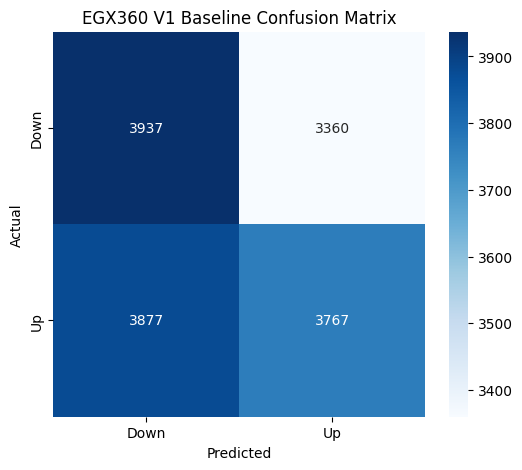

In [45]:
cm = confusion_matrix(y_test, final_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Down', 'Up'], yticklabels=['Down', 'Up'])
plt.title("EGX360 V1 Baseline Confusion Matrix")
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

📥 Loading Daily Data & Sentiment...
⚙️ Engineering Advanced Quant Features...
🧠 Training The Deep Quant Ensemble (V8.4)...

📊 Evaluating Final Performance...

✅ DEEP QUANT ACCURACY: 84.28%

🔥 Classification Report:
                precision    recall  f1-score   support

Down Trend (0)       0.78      0.82      0.80       515
  Up Trend (1)       0.89      0.86      0.87       846

      accuracy                           0.84      1361
     macro avg       0.83      0.84      0.83      1361
  weighted avg       0.85      0.84      0.84      1361



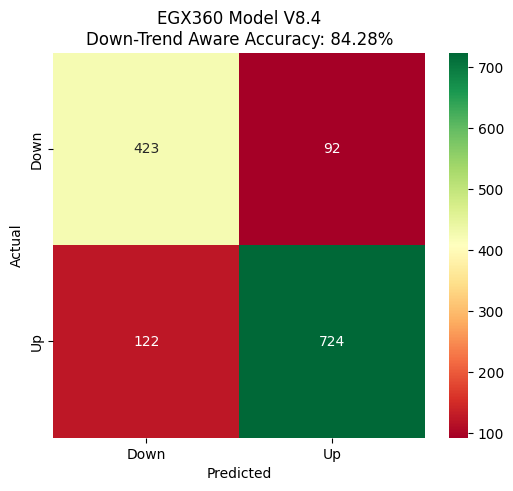

In [ ]:
# ==========================================
# EGX360 — THE DEEP QUANT MODEL (V8.4)
# Enhancing Down-Trend Detection & Bias Control
# ==========================================

import pandas as pd
import numpy as np
import xgboost as xgb
import lightgbm as lgb
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import StackingClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

# 1. Load Data
print("📥 Loading Daily Data & Sentiment...")
df = pd.read_csv("data/EGX30D_processed.csv")

df['timestamp'] = pd.to_datetime(df['timestamp'])
df.sort_values('timestamp', inplace=True)

print("⚙️ Engineering Advanced Quant Features...")

# --- A. Log Returns & Momentum Acceleration ---
# إضافة epsilon لتجنب الـ Infinity
df['log_ret'] = np.log((df['close'] + 1e-6) / (df['close'].shift(1) + 1e-6))
df['vol_log_ret'] = np.log((df['volume'] + 1e-6) / (df['volume'].shift(1) + 1e-6))

# ميزة تسارع السعر (Velocity): هل الهبوط يتسارع؟
df['price_velocity'] = df['log_ret'].diff()

# --- B. Cyclic Time Features ---
df['day_sin'] = np.sin(2 * np.pi * df['timestamp'].dt.dayofweek / 7)
df['day_cos'] = np.cos(2 * np.pi * df['timestamp'].dt.dayofweek / 7)

# --- C. The Winning EMAs & Gap Analysis ---
for period in [9, 21, 50]:
    ema_col = f'EMA_{period}'
    df[ema_col] = df['close'].ewm(span=period).mean()
    # المسافة بين السعر والمتوسط
    df[f'dist_EMA_{period}'] = (df['close'] - df[ema_col]) / (df[ema_col] + 1e-9)

# ميزة "كسر المتوسط": هل السعر تحت الـ EMA_9؟ (مهمة جداً للوقوعان)
df['below_EMA9'] = (df['close'] < df['EMA_9']).astype(int)

# --- D. Momentum & Volatility (RSI, MACD, ATR) ---
delta = df['close'].diff()
gain = delta.where(delta > 0, 0).rolling(14).mean()
loss = (-delta.where(delta < 0, 0)).rolling(14).mean()
df['RSI'] = 100 - (100 / (1 + gain/(loss + 1e-9)))

# ميزة RSI Velocity: هل قوة الشراء تنهار؟
df['RSI_diff'] = df['RSI'].diff()

macd = df['close'].ewm(span=12).mean() - df['close'].ewm(span=26).mean()
df['MACD_Hist'] = macd - macd.ewm(span=9).mean()

tr = pd.concat([df['high'] - df['low'], 
                np.abs(df['high'] - df['close'].shift()), 
                np.abs(df['low'] - df['close'].shift())], axis=1).max(axis=1)
df['ATR_pct'] = tr.rolling(14).mean() / (df['close'] + 1e-9)

# --- E. Panic Detectors (Stoch & BB) ---
low_14 = df['low'].rolling(14).min()
high_14 = df['high'].rolling(14).max()
df['Stoch_K'] = 100 * ((df['close'] - low_14) / (high_14 - low_14 + 1e-9))

ma20 = df['close'].rolling(20).mean()
std20 = df['close'].rolling(20).std()
df['BB_Width'] = (std20 * 4) / (ma20 + 1e-9)

# Lags
df['log_ret_lag1'] = df['log_ret'].shift(1)
df['RSI_lag1'] = df['RSI'].shift(1)

# --- F. Target (Directional Trend) ---
# التنبؤ باتجاه الـ EMA غداً (منطق المنصات مع تأمين البيانات)
df['Target'] = (df['close'].ewm(span=10).mean().shift(-1) > df['close'].ewm(span=10).mean()).astype(int)

# تنظيف نهائي من أي قيم Infinity أو NaN
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(inplace=True)

# تجميعة الميزات المطورة (18 ميزة)
final_features = [
    'log_ret', 'vol_log_ret', 'price_velocity',
    'day_sin', 'day_cos', 
    'dist_EMA_9', 'dist_EMA_21', 'dist_EMA_50', 'below_EMA9',
    'RSI', 'RSI_diff', 'MACD_Hist', 'ATR_pct',
    'Stoch_K', 'BB_Width',
    'log_ret_lag1', 'RSI_lag1'
]

X = df[final_features].values
y = df['Target'].values

# 3. Train/Test Split
split = int(len(X) * 0.80)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# 4. Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
joblib.dump(scaler, "egx360_scaler_quant.pkl")

# 5. Build Advanced Stacking Ensemble (With Down-Trend Focus)
print("🧠 Training The Deep Quant Ensemble (V8.4)...")

# موديلات الأساس
base_models = [
    ('xgb', xgb.XGBClassifier(n_estimators=500, max_depth=4, learning_rate=0.02, 
                              subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1)),
    ('lgbm', lgb.LGBMClassifier(n_estimators=500, max_depth=4, learning_rate=0.02, 
                                subsample=0.8, colsample_bytree=0.8, random_state=42, verbose=-1, n_jobs=-1))
]

# المدير (Final Estimator) مع إعطاء وزن أكبر للهبوط (Class 0) لتعويض الـ Bias
# class_weight={0: 1.5, 1: 1.0} تعني أن الخطأ في توقع الهبوط عقوبته أكبر بـ 50%
final_logic = LogisticRegression(C=0.1, class_weight={0: 1.5, 1: 1.0})

stack_model = StackingClassifier(estimators=base_models, final_estimator=final_logic, cv=5)

stack_model.fit(X_train_scaled, y_train)
joblib.dump(stack_model, "EGX360_Quant_Model_V84.pkl")

# 6. Evaluation
print("\n📊 Evaluating Final Performance...")
y_pred = stack_model.predict(X_test_scaled)

acc = accuracy_score(y_test, y_pred) * 100
print(f"\n✅ DEEP QUANT ACCURACY: {acc:.2f}%")
print("\n🔥 Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Down Trend (0)', 'Up Trend (1)']))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='RdYlGn', xticklabels=['Down', 'Up'], yticklabels=['Down', 'Up'])
plt.title(f"EGX360 Model V8.4\nDown-Trend Aware Accuracy: {acc:.2f}%")
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()